In [1]:
import sys; sys.path.append("..")
import pandas as pd, matplotlib.pyplot as plt, shap, lightgbm as lgb
from src.data import get_model_data

X, y, thang = get_model_data()
tr, te = thang.isin([3,4]), thang == 5

# chuyển cột chữ sang category (giống lúc train trong model.py)
cat = list(X.select_dtypes(["object","category"]).columns)
Xc = X.copy()
for c in cat:
    Xc[c] = Xc[c].astype("category")

model = lgb.LGBMClassifier(n_estimators=300, min_child_samples=100,
                           random_state=42, verbose=-1)
model.fit(Xc[tr], y[tr], categorical_feature=cat)
print("Trained. Test rows:", te.sum())

/Users/ngantran/Projects/viettel-package-stickiness/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Trained. Test rows: 59603


In [2]:
# lấy 2000 dòng test cho nhanh & ổn định
X_test = Xc[te].sample(2000, random_state=42)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values
print("SHAP shape:", sv.shape)   # (2000, số_feature)

SHAP shape: (2000, 18)


/Users/ngantran/Projects/viettel-package-stickiness/.venv/lib/python3.9/site-packages/shap/explainers/_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


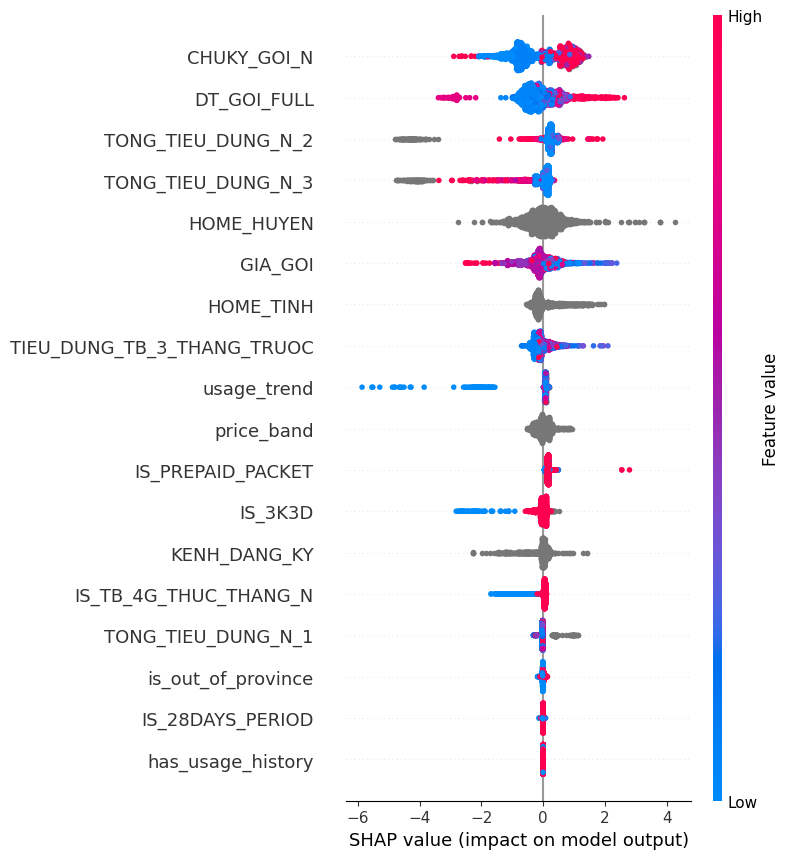

In [3]:
shap.summary_plot(sv, X_test, show=False)
plt.tight_layout()
plt.savefig("../reports/figures/shap_summary.png", dpi=120, bbox_inches="tight")
plt.show()

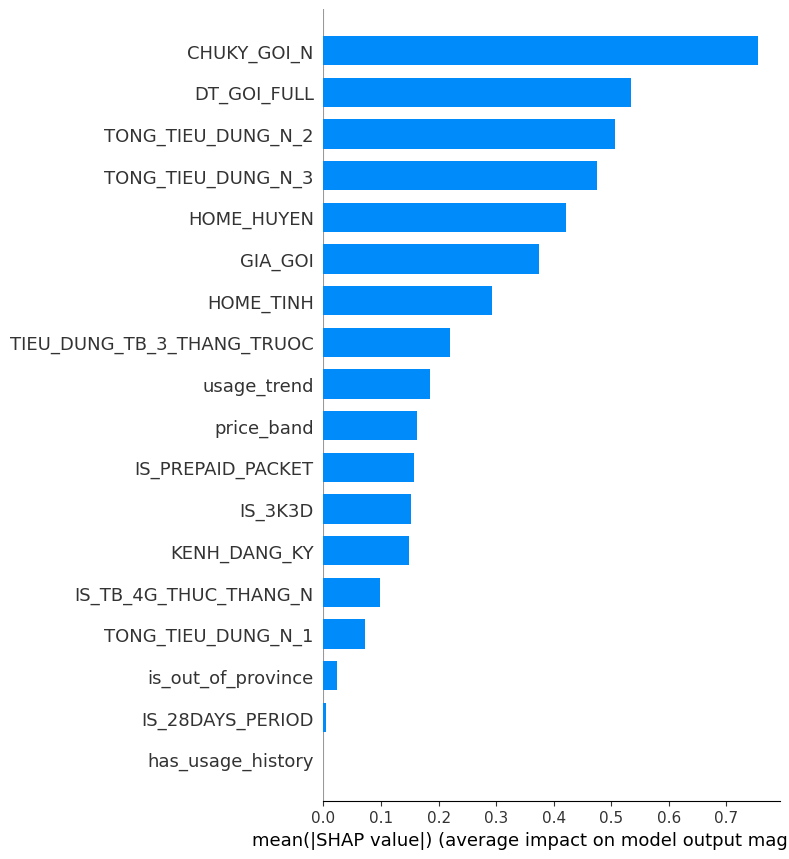

In [4]:
shap.summary_plot(sv, X_test, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig("../reports/figures/shap_importance.png", dpi=120, bbox_inches="tight")
plt.show()

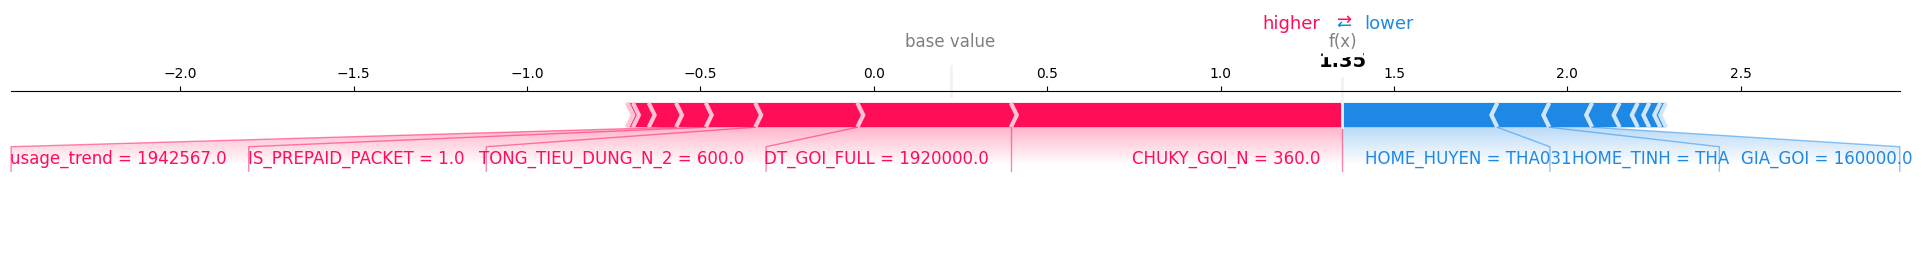

Dự đoán cho dòng này: 0.794


In [5]:
i = 0  
shap.force_plot(explainer.expected_value[1] if isinstance(explainer.expected_value, (list, "list".__class__)) else explainer.expected_value,
                sv[i], X_test.iloc[i], matplotlib=True, show=False)
plt.tight_layout(); plt.show()
print("Dự đoán cho dòng này:", model.predict_proba(X_test.iloc[[i]])[0,1].round(3))

In [7]:
from src.data import get_model_data
X, y, thang = get_model_data()
g = X.assign(y=y.values).groupby("DT_GOI_FULL")["y"].agg(["mean","count"])
print(g[g["count"]>=200].sort_values("mean").head(8))   # giá trị phổ biến sống ~0%?
print(g[g["count"]>=200].sort_values("mean").tail(3))

                 mean  count
DT_GOI_FULL                 
1500000      0.045333   4103
160000       0.181222   8542
230000       0.184783    276
250000       0.191153   1266
100000       0.264435  10755
180000       0.272189   1859
90000        0.298376   2832
120000       0.319476  24969
                 mean  count
DT_GOI_FULL                 
1440000      0.944100  12576
720000       0.952948   6546
2400000      0.974314   5139
